# 01 — EDA inicial (Stellar Classification SDSS17)

> **Fase 1-2 del playbook DS3022** — Carga + sanity check + análisis exploratorio.
>
> Replica el flujo del notebook base del profe (`Recomendación_producto.ipynb`) sobre el dataset SDSS17 (3 clases: Galaxy / Star / Quasar).

## Definition of Done (Día 1)
- [ ] Dataset cargado correctamente (100K filas, 18 columnas).
- [ ] `value_counts()` confirma 3 clases con balance ~59/22/19.
- [ ] Sin nulls relevantes (o documentados si los hay).
- [ ] Heatmap de correlación generado.
- [ ] Scatterplot alpha vs delta coloreado por clase generado.
- [ ] Boxplot de redshift por clase generado.
- [ ] Columnas metadata identificadas para descartar.

## Setup
Bajar el dataset desde Kaggle ANTES de correr este notebook:
```bash
kaggle datasets download -d fedesoriano/stellar-classification-dataset-sdss17 -p ../backend/data --unzip
# o manualmente desde: https://www.kaggle.com/datasets/fedesoriano/stellar-classification-dataset-sdss17
```
Resultado: `../backend/data/star_classification.csv`.

## Fase 1 — Carga + sanity check

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

DATA_PATH = Path('../backend/data/star_classification.csv')
assert DATA_PATH.exists(), f'Dataset no encontrado en {DATA_PATH}. Ver instrucciones de descarga arriba.'

df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
df.head()

Shape: (100000, 18)


,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  object 
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     100000 non-null  int64  
dtypes: float64(10), int64(7),

In [3]:
# Sanity check: nulls + duplicados
print('Nulls por columna:')
print(df.isnull().sum())
print(f'\nFilas duplicadas: {df.duplicated().sum()}')

Nulls por columna:
obj_ID         0
alpha          0
delta          0
u              0
g              0
r              0
i              0
z              0
run_ID         0
rerun_ID       0
cam_col        0
field_ID       0
spec_obj_ID    0
class          0
redshift       0
plate          0
MJD            0
fiber_ID       0
dtype: int64

Filas duplicadas: 0


In [4]:
df.describe()

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,redshift,plate,MJD,fiber_ID
count,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.0,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000
mean,1.237665e+18,177.629117,24.135305,21.980468,20.531387,19.645762,19.084854,18.668810,4481.366060,301.0,3.511610,186.130520,5.783882e+18,0.576661,5137.009660,55588.647500,449.312740
std,8.438560e+12,96.502241,19.644665,31.769291,31.750292,1.854760,1.757895,31.728152,1964.764593,0.0,1.586912,149.011073,3.324016e+18,0.730707,2952.303351,1808.484233,272.498404
min,1.237646e+18,0.005528,-18.785328,-9999.000000,-9999.000000,9.822070,9.469903,-9999.000000,109.000000,301.0,1.000000,11.000000,2.995191e+17,-0.009971,266.000000,51608.000000,1.000000
25%,1.237659e+18,127.518222,5.146771,20.352353,18.965230,18.135828,17.732285,17.460677,3187.000000,301.0,2.000000,82.000000,2.844138e+18,0.054517,2526.000000,54234.000000,221.000000
50%,1.237663e+18,180.900700,23.645922,22.179135,21.099835,20.125290,19.405145,19.004595,4188.000000,301.0,4.000000,146.000000,5.614883e+18,0.424173,4987.000000,55868.500000,433.000000
75%,1.237668e+18,233.895005,39.901550,23.687440,22.123767,21.044785,20.396495,19.921120,5326.000000,301.0,5.000000,241.000000,8.332144e+18,0.704154,7400.250000,56777.000000,645.000000
max,1.237681e+18,359.999810,83.000519,32.781390,31.602240,29.571860,32.141470,29.383740,8162.000000,301.0,6.000000,989.000000,1.412694e+19,7.011245,12547.000000,58932.000000,1000.000000


### Columnas metadata a descartar para el modelo

Estas columnas son IDs internos del SDSS — no tienen valor predictivo y pueden causar data leakage si correlacionan con la clase por sesgo de muestreo.

In [5]:
METADATA_COLS = ['obj_ID', 'run_ID', 'rerun_ID', 'cam_col', 'field_ID',
                 'spec_obj_ID', 'plate', 'MJD', 'fiber_ID']

FEATURE_COLS = ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']
TARGET_COL = 'class'

# Verificar que existen
for col in FEATURE_COLS + [TARGET_COL]:
    assert col in df.columns, f'Columna {col} no existe en el dataset'

print(f'Features predictivas: {FEATURE_COLS}')
print(f'Target: {TARGET_COL}')
print(f'Metadata descartada: {[c for c in METADATA_COLS if c in df.columns]}')

Features predictivas: ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']
Target: class
Metadata descartada: ['obj_ID', 'run_ID', 'rerun_ID', 'cam_col', 'field_ID', 'spec_obj_ID', 'plate', 'MJD', 'fiber_ID']


## Fase 2 — EDA

### Balance de clases

In [6]:
class_counts = df[TARGET_COL].value_counts()
class_pct = df[TARGET_COL].value_counts(normalize=True) * 100

print('Balance de clases:')
for cls in class_counts.index:
    print(f'  {cls:8s}: {class_counts[cls]:>7d} ({class_pct[cls]:>5.2f}%)')

Balance de clases:
  GALAXY  :   59445 (59.45%)
  STAR    :   21594 (21.59%)
  QSO     :   18961 (18.96%)


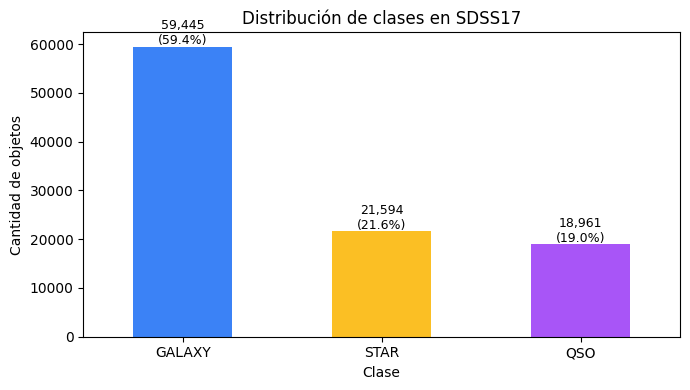

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
class_counts.plot(kind='bar', ax=ax, color=['#3b82f6', '#fbbf24', '#a855f7'])
ax.set_title('Distribución de clases en SDSS17')
ax.set_xlabel('Clase')
ax.set_ylabel('Cantidad de objetos')
ax.tick_params(axis='x', rotation=0)
for i, v in enumerate(class_counts.values):
    ax.text(i, v + 500, f'{v:,}\n({class_pct.iloc[i]:.1f}%)', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

### Heatmap de correlaciones (features numéricas)

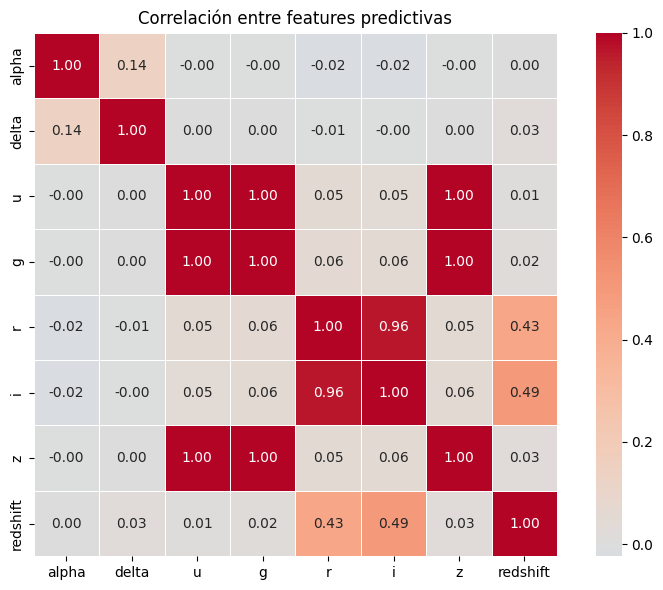

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))
corr = df[FEATURE_COLS].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlación entre features predictivas')
plt.tight_layout()
plt.show()

**Insight esperado**: las bandas fotométricas `u, g, r, i, z` tienen correlación alta entre sí (son del mismo objeto a diferentes longitudes de onda). Esto **justifica descartar Naive Bayes** (que asume independencia condicional).

### Distribuciones por feature

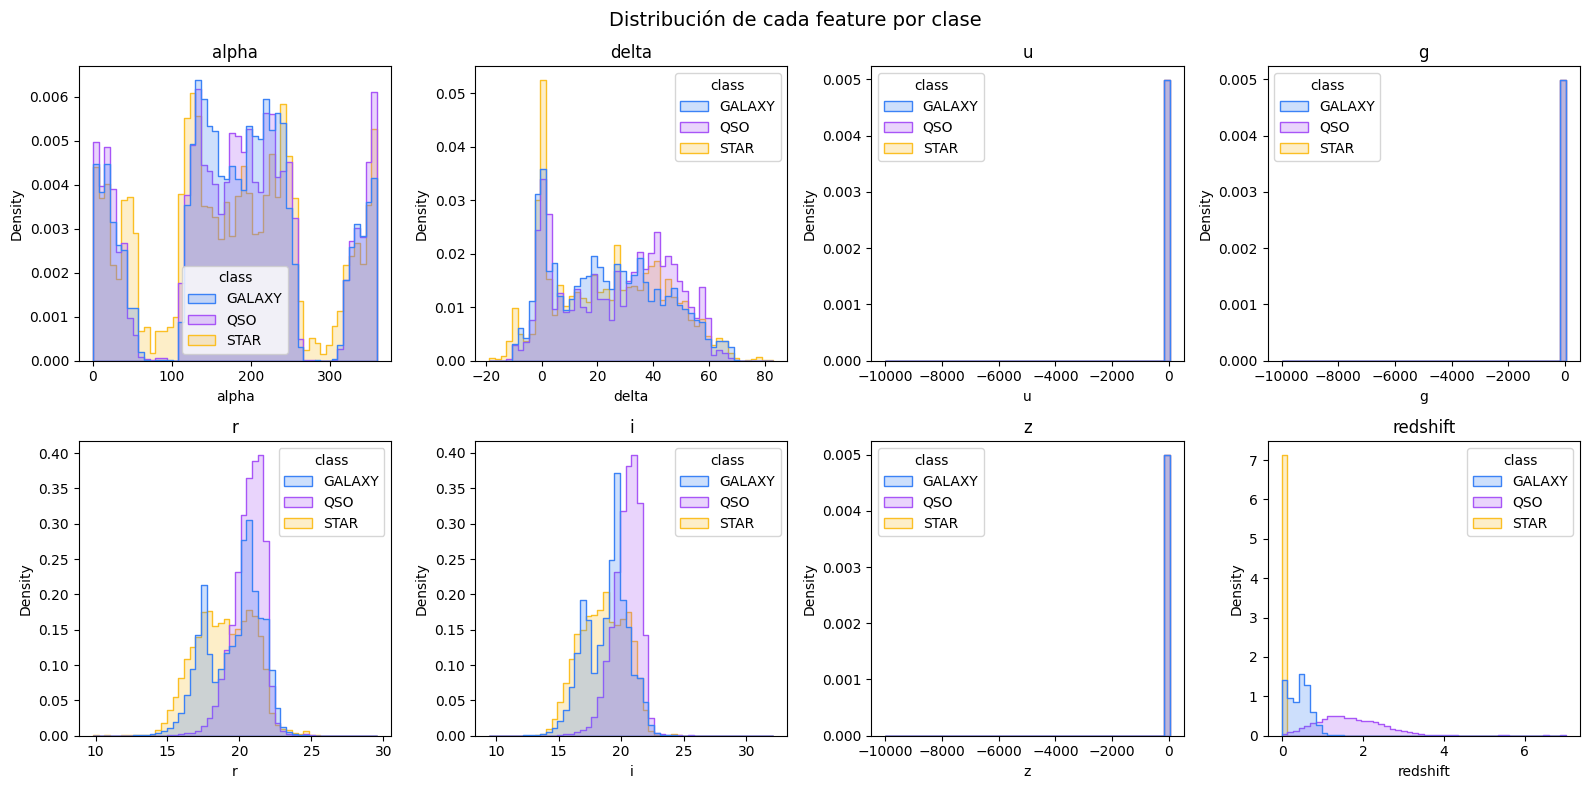

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, col in zip(axes.flat, FEATURE_COLS):
    sns.histplot(data=df, x=col, hue=TARGET_COL, ax=ax,
                 palette={'GALAXY': '#3b82f6', 'STAR': '#fbbf24', 'QSO': '#a855f7'},
                 bins=50, element='step', stat='density', common_norm=False)
    ax.set_title(col)
plt.suptitle('Distribución de cada feature por clase', fontsize=14)
plt.tight_layout()
plt.show()

### Boxplot de `redshift` por clase

Esta es la feature más discriminante esperada: STAR ≈ 0 (objetos dentro de la Vía Láctea), GALAXY medio (universo cercano), QSO alto (objetos muy distantes).

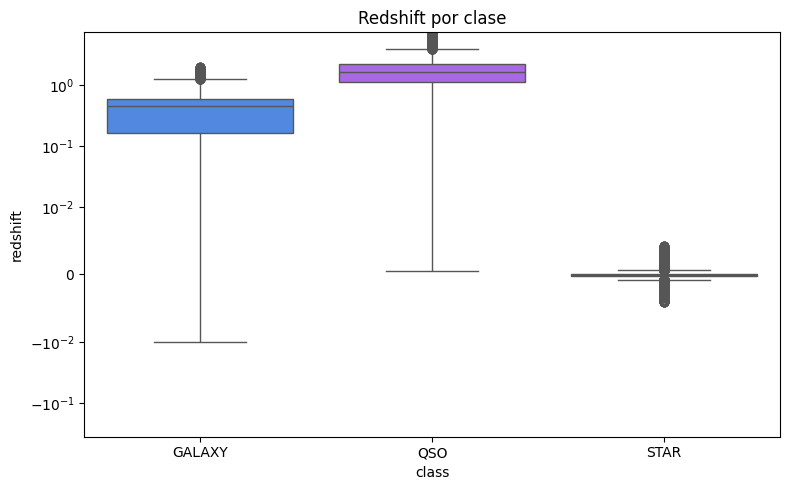

Estadísticas de redshift por clase:
            mean       std       min       50%       max
class                                                   
GALAXY  0.421596  0.264858 -0.009971  0.456274  1.995524
QSO     1.719676  0.913954  0.000461  1.617232  7.011245
STAR   -0.000115  0.000465 -0.004136 -0.000076  0.004153


In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x=TARGET_COL, y='redshift', hue=TARGET_COL, ax=ax,
            palette={'GALAXY': '#3b82f6', 'STAR': '#fbbf24', 'QSO': '#a855f7'},
            legend=False)
ax.set_title('Redshift por clase')
ax.set_yscale('symlog', linthresh=0.01)
plt.tight_layout()
plt.show()

print('Estadísticas de redshift por clase:')
print(df.groupby(TARGET_COL)['redshift'].describe()[['mean', 'std', 'min', '50%', 'max']])

### Scatter plot crudo del cielo (alpha vs delta)

Preview del mapa del cielo — Quadtree 2D se construirá en notebook 04.

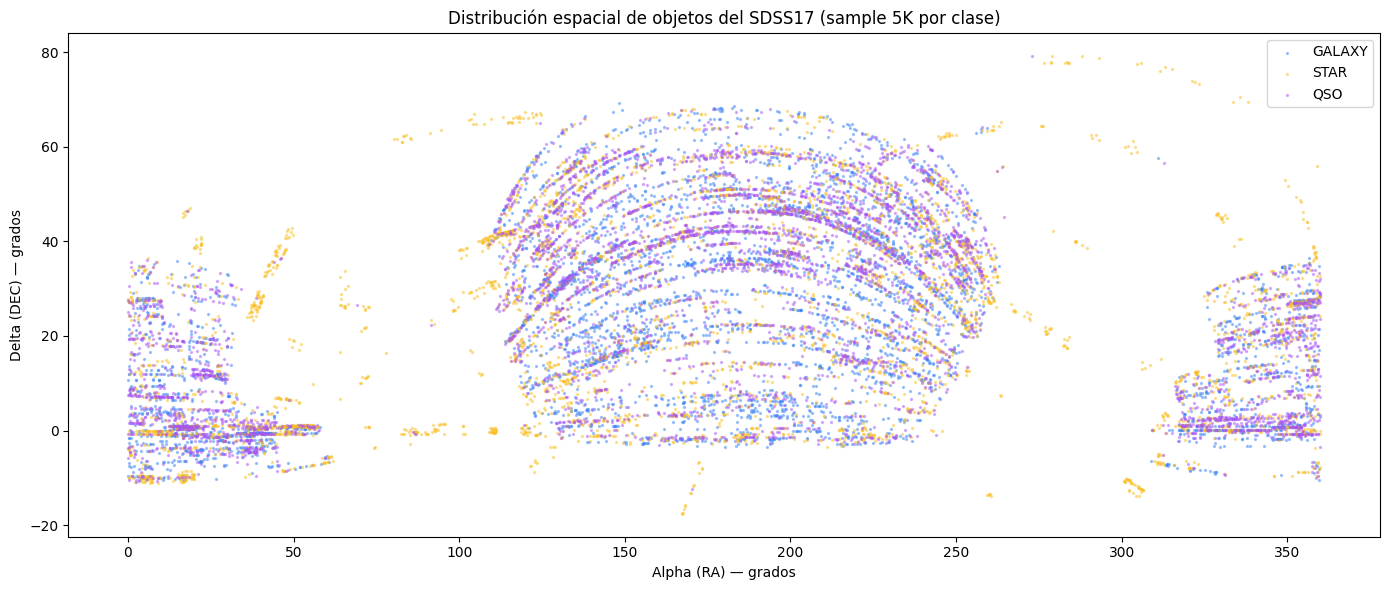

In [11]:
fig, ax = plt.subplots(figsize=(14, 6))
for cls, color in [('GALAXY', '#3b82f6'), ('STAR', '#fbbf24'), ('QSO', '#a855f7')]:
    subset = df[df[TARGET_COL] == cls].sample(min(5000, len(df[df[TARGET_COL] == cls])), random_state=42)
    ax.scatter(subset['alpha'], subset['delta'], s=2, alpha=0.4, c=color, label=cls)
ax.set_xlabel('Alpha (RA) — grados')
ax.set_ylabel('Delta (DEC) — grados')
ax.set_title('Distribución espacial de objetos del SDSS17 (sample 5K por clase)')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

## Resumen del EDA (output para `docs/`)

### Detección de valores centinela SDSS (`-9999`)

SDSS usa `-9999` como código de "valor no medido / observación fallida". Aunque `isnull()` devuelva 0, estos valores son nulls semánticos y deben tratarse como tales.

In [12]:
SENTINEL_VALUE = -9999
PHOTOMETRIC_BANDS = ['u', 'g', 'r', 'i', 'z']

sentinel_per_band = {col: int((df[col] == SENTINEL_VALUE).sum()) for col in PHOTOMETRIC_BANDS}
print('Valores -9999 por banda fotométrica:')
for band, count in sentinel_per_band.items():
    print(f'  {band}: {count}')

mask_sentinel = (df[PHOTOMETRIC_BANDS] == SENTINEL_VALUE).any(axis=1)
n_sentinel_rows = int(mask_sentinel.sum())
pct_sentinel = float(mask_sentinel.mean() * 100)

print(f'\nFilas con al menos un -9999: {n_sentinel_rows} ({pct_sentinel:.4f}%)')
if n_sentinel_rows > 0:
    print(f'Clase de las filas afectadas:')
    print(df.loc[mask_sentinel, TARGET_COL].value_counts())

print('\nDecisión: drop estas filas en notebook 02 (es <0.01%, no vale imputar).')

# Ranges REALES post-limpieza
df_clean = df[~mask_sentinel]
clean_ranges = {col: {'min': float(df_clean[col].min()), 'max': float(df_clean[col].max())} for col in FEATURE_COLS}
print('\nRanges reales (excluyendo centinelas):')
for col, r in clean_ranges.items():
    print(f'  {col}: [{r["min"]:.3f}, {r["max"]:.3f}]')

Valores -9999 por banda fotométrica:
  u: 1
  g: 1
  r: 0
  i: 0
  z: 1

Filas con al menos un -9999: 1 (0.0010%)
Clase de las filas afectadas:
class
STAR    1
Name: count, dtype: int64

Decisión: drop estas filas en notebook 02 (es <0.01%, no vale imputar).

Ranges reales (excluyendo centinelas):
  alpha: [0.006, 360.000]
  delta: [-18.785, 83.001]
  u: [10.996, 32.781]
  g: [10.498, 31.602]
  r: [9.822, 29.572]
  i: [9.470, 32.141]
  z: [9.612, 29.384]
  redshift: [-0.010, 7.011]


In [13]:
import json
from datetime import datetime

eda_summary = {
    'timestamp': datetime.utcnow().isoformat() + 'Z',
    'dataset_shape': list(df.shape),
    'features': FEATURE_COLS,
    'target': TARGET_COL,
    'metadata_dropped': [c for c in METADATA_COLS if c in df.columns],
    'class_counts': class_counts.to_dict(),
    'class_proportions': class_pct.round(2).to_dict(),
    'nulls_total': int(df.isnull().sum().sum()),
    'duplicates_total': int(df.duplicated().sum()),
    'sentinel_rows_detected': n_sentinel_rows,
    'sentinel_per_band': sentinel_per_band,
    'feature_ranges_raw': {
        col: {'min': float(df[col].min()), 'max': float(df[col].max())}
        for col in FEATURE_COLS
    },
    'feature_ranges_clean': clean_ranges,
    'decisions': [
        'Drop filas con -9999 en notebook 02 (preprocessing) — son centinelas SDSS, no datos reales.',
        f'Descartar {len([c for c in METADATA_COLS if c in df.columns])} columnas metadata (IDs sin valor predictivo).',
        'Usar feature_ranges_clean para validar inputs en producción (no feature_ranges_raw).'
    ]
}

OUTPUT_PATH = Path('../docs/eda_summary.json')
OUTPUT_PATH.write_text(json.dumps(eda_summary, indent=2))
print(f'Resumen guardado en {OUTPUT_PATH}')
print(json.dumps(eda_summary, indent=2))

Resumen guardado en ../docs/eda_summary.json
{
  "timestamp": "2026-05-27T05:28:13.666668Z",
  "dataset_shape": [
    100000,
    18
  ],
  "features": [
    "alpha",
    "delta",
    "u",
    "g",
    "r",
    "i",
    "z",
    "redshift"
  ],
  "target": "class",
  "metadata_dropped": [
    "obj_ID",
    "run_ID",
    "rerun_ID",
    "cam_col",
    "field_ID",
    "spec_obj_ID",
    "plate",
    "MJD",
    "fiber_ID"
  ],
  "class_counts": {
    "GALAXY": 59445,
    "STAR": 21594,
    "QSO": 18961
  },
  "class_proportions": {
    "GALAXY": 59.44,
    "STAR": 21.59,
    "QSO": 18.96
  },
  "nulls_total": 0,
  "duplicates_total": 0,
  "sentinel_rows_detected": 1,
  "sentinel_per_band": {
    "u": 1,
    "g": 1,
    "r": 0,
    "i": 0,
    "z": 1
  },
  "feature_ranges_raw": {
    "alpha": {
      "min": 0.0055278279239701,
      "max": 359.999809770956
    },
    "delta": {
      "min": -18.7853280771825,
      "max": 83.00051858898
    },
    "u": {
      "min": -9999.0,
      "max":

## Decisiones tomadas en este notebook

1. **Columnas a usar como features**: `alpha, delta, u, g, r, i, z, redshift` (8 columnas).
2. **Columnas descartadas**: 8-9 IDs metadata (obj_ID, run_ID, rerun_ID, cam_col, field_ID, spec_obj_ID, plate, MJD, fiber_ID).
3. **Tratamiento de nulls**: confirmar arriba si hay alguno; si los hay <1%, drop row; si >1%, imputar mediana.
4. **Tratamiento de duplicados**: drop si los hay (sospechoso en un dataset profesional, pero validar).
5. **Redshift outliers**: NO descartar — los valores altos (~6-7) son QSO reales muy distantes, no errores.

## Siguiente paso
Continuar con `02_preprocessing.ipynb`: encoding del target, train/test split con `stratify=y`, StandardScaler (split ANTES de scaler — Slide 39 U3_T2).